# GAN Analysis for MNIST

This notebook addresses Part II Tasks 2 and 3:
- Task 2: Sample 25 images at start, halfway, and end of training
- Task 3: Interpolate between two different digit classes in latent space

In [10]:
! python my_gan.py --n_epochs 100 # use this to train the GAN

Using device: cpu
[Epoch 0/100] [Batch 0/938] [D loss: 1.3870] [G loss: 0.6953]
[Epoch 0/100] [Batch 500/938] [D loss: 1.3587] [G loss: 0.9767]
[Epoch 1/100] [Batch 62/938] [D loss: 1.3153] [G loss: 0.6809]
[Epoch 1/100] [Batch 562/938] [D loss: 1.2088] [G loss: 0.9609]
[Epoch 2/100] [Batch 124/938] [D loss: 1.2083] [G loss: 0.9580]
[Epoch 2/100] [Batch 624/938] [D loss: 1.1816] [G loss: 1.3066]
[Epoch 3/100] [Batch 186/938] [D loss: 1.4240] [G loss: 0.5783]
[Epoch 3/100] [Batch 686/938] [D loss: 1.3102] [G loss: 0.9163]
[Epoch 4/100] [Batch 248/938] [D loss: 1.1712] [G loss: 1.2451]
[Epoch 4/100] [Batch 748/938] [D loss: 1.1743] [G loss: 1.0371]
[Epoch 5/100] [Batch 310/938] [D loss: 1.2922] [G loss: 0.7368]
[Epoch 5/100] [Batch 810/938] [D loss: 1.1942] [G loss: 0.9553]
[Epoch 6/100] [Batch 372/938] [D loss: 1.2432] [G loss: 0.7191]
[Epoch 6/100] [Batch 872/938] [D loss: 1.2134] [G loss: 0.9392]
[Epoch 7/100] [Batch 434/938] [D loss: 1.4025] [G loss: 1.8186]
[Epoch 7/100] [Batch 934/

In [11]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import os

# Import Generator from my_gan
from my_gan import Generator, Discriminator

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

latent_dim = 100

Using device: cpu


## Task 2: Sample 25 Images at Different Training Stages

Display generated images from:
1. Start of training (iteration 0)
2. Halfway through training
3. End of training

In [13]:
def show_generated_images(image_path, title):
    """Display a saved image from training."""
    if os.path.exists(image_path):
        img = plt.imread(image_path)
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.title(title, fontsize=14)
        plt.axis('off')
        plt.show()
    else:
        print(f"Image not found: {image_path}")

def generate_and_show_images(generator, n_images=25, title="Generated Images"):
    """Generate and display images using the generator."""
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_images, latent_dim).to(device)
        gen_imgs = generator(z)
        gen_imgs = (gen_imgs + 1) / 2  # Denormalize from [-1,1] to [0,1]
        
    # Create grid
    grid = make_grid(gen_imgs.cpu(), nrow=5, padding=2)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.show()
    
    return gen_imgs

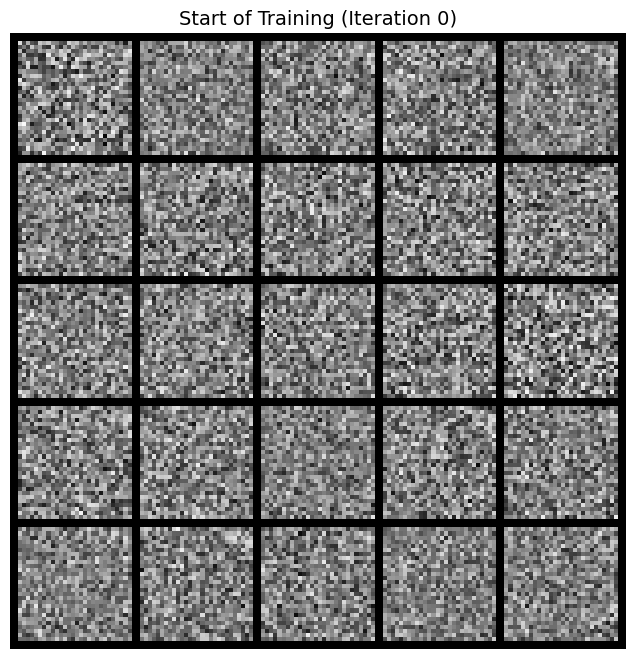

In [14]:
# Display images saved during training
# These are saved at intervals during training by my_gan.py

# Start of training (iteration 0)
show_generated_images('images/0.png', 'Start of Training (Iteration 0)')

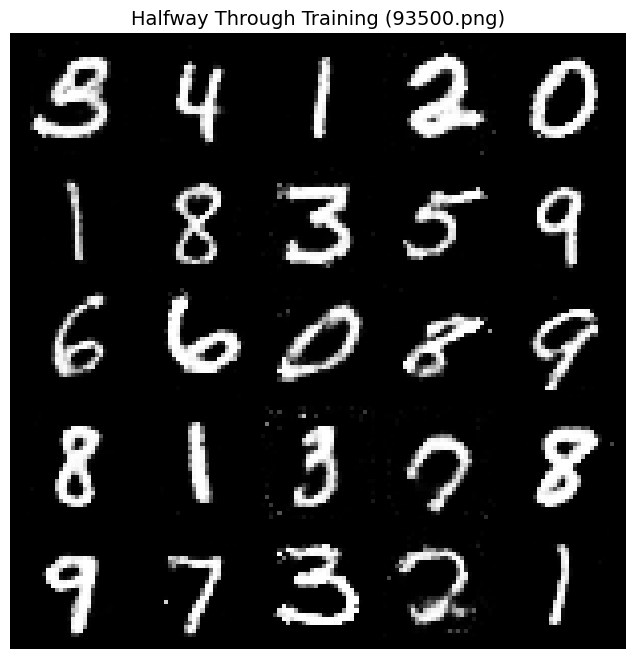

In [15]:
# Halfway through training
# With 200 epochs and ~938 batches per epoch, halfway is around iteration 93800
# Find the closest saved image
import glob

saved_images = sorted(glob.glob('images/*.png'), key=lambda x: int(os.path.basename(x).split('.')[0]))
if saved_images:
    total_iterations = int(os.path.basename(saved_images[-1]).split('.')[0])
    halfway_iter = total_iterations // 2
    # Find closest saved image to halfway
    closest_halfway = min(saved_images, key=lambda x: abs(int(os.path.basename(x).split('.')[0]) - halfway_iter))
    show_generated_images(closest_halfway, f'Halfway Through Training ({os.path.basename(closest_halfway)})')
else:
    print("No saved images found. Please run training first.")

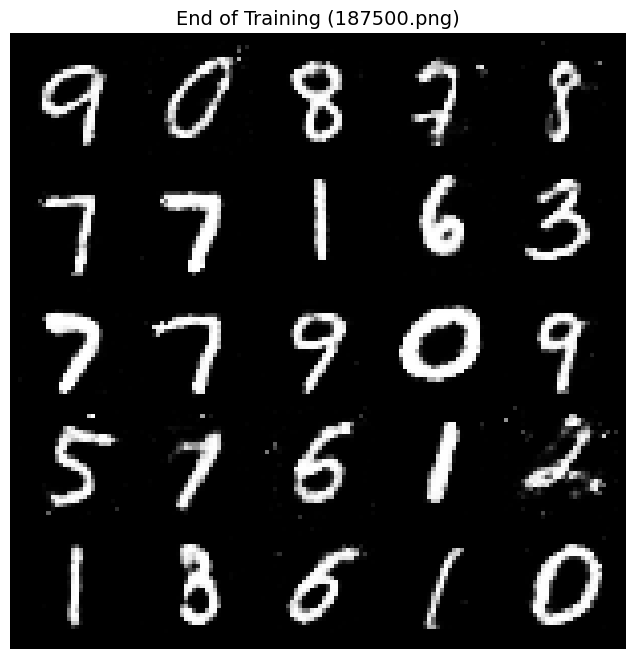

In [17]:
# End of training (last saved image)
if saved_images:
    show_generated_images(saved_images[-1], f'End of Training ({os.path.basename(saved_images[-1])})')
else:
    print("No saved images found. Please run training first.")

Loaded trained generator


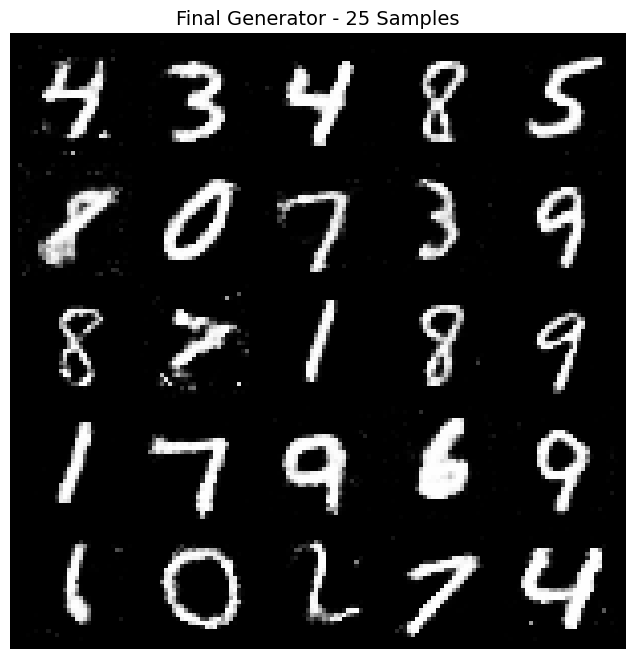

In [18]:
# Load the trained generator and generate fresh samples
generator = Generator(latent_dim=latent_dim).to(device)

if os.path.exists('mnist_generator.pt'):
    generator.load_state_dict(torch.load('mnist_generator.pt', map_location=device))
    print("Loaded trained generator")
    generate_and_show_images(generator, n_images=25, title="Final Generator - 25 Samples")
else:
    print("Trained generator not found. Please run training first.")

## Task 3: Latent Space Interpolation

Sample 2 images from different classes and interpolate between them in latent space.
Use 7 interpolation steps, resulting in 9 images (including start and end points).

In [19]:
def interpolate_latent_space(generator, z1, z2, n_steps=7):
    """
    Interpolate between two latent vectors.
    
    Args:
        generator: Trained generator model
        z1: Starting latent vector
        z2: Ending latent vector
        n_steps: Number of interpolation steps (excluding endpoints)
    
    Returns:
        List of generated images along the interpolation path
    """
    generator.eval()
    
    # Create interpolation weights (0 to 1, inclusive)
    alphas = np.linspace(0, 1, n_steps + 2)  # +2 for start and end points
    
    interpolated_images = []
    
    with torch.no_grad():
        for alpha in alphas:
            # Linear interpolation in latent space
            z_interp = (1 - alpha) * z1 + alpha * z2
            img = generator(z_interp)
            interpolated_images.append(img)
    
    return interpolated_images, alphas

In [20]:
def find_different_digit_samples(generator, n_samples=100):
    """
    Generate multiple samples and let user select two that look like different digits.
    Returns two latent vectors that produce visually different outputs.
    """
    generator.eval()
    
    # Generate multiple random latent vectors
    z_samples = torch.randn(n_samples, latent_dim).to(device)
    
    with torch.no_grad():
        gen_imgs = generator(z_samples)
        gen_imgs = (gen_imgs + 1) / 2  # Denormalize
    
    # Display samples for selection
    fig, axes = plt.subplots(10, 10, figsize=(12, 12))
    for idx, ax in enumerate(axes.flat):
        if idx < n_samples:
            ax.imshow(gen_imgs[idx, 0].cpu().numpy(), cmap='gray')
            ax.set_title(str(idx), fontsize=8)
        ax.axis('off')
    plt.suptitle('Select two indices with different digit classes', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return z_samples

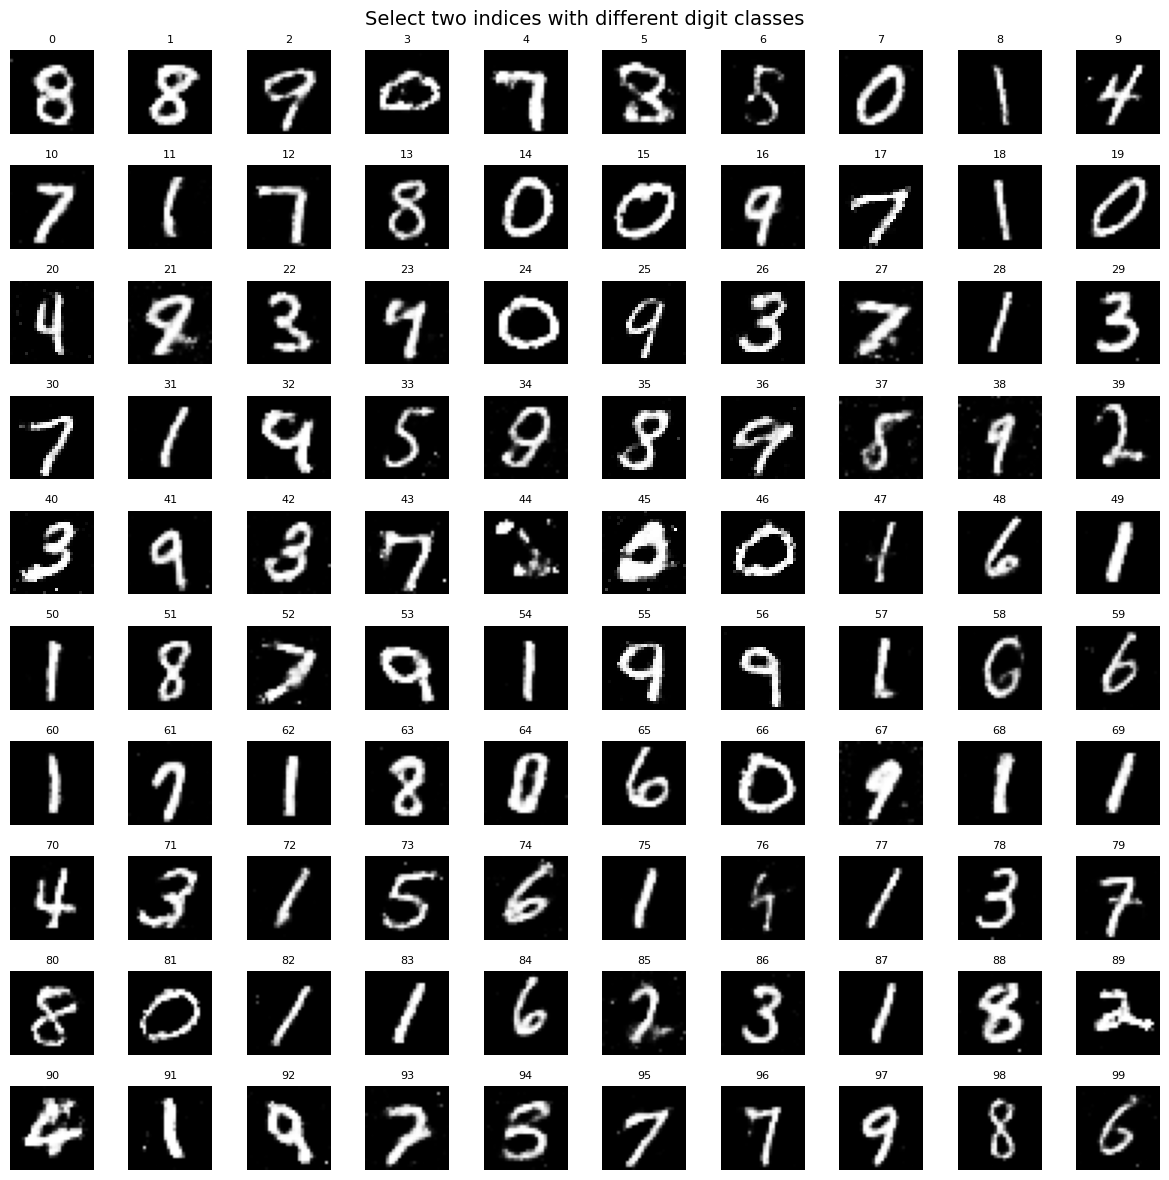

In [21]:
# Generate samples to find two different digits
if os.path.exists('mnist_generator.pt'):
    generator = Generator(latent_dim=latent_dim).to(device)
    generator.load_state_dict(torch.load('mnist_generator.pt', map_location=device))
    
    z_samples = find_different_digit_samples(generator, n_samples=100)
else:
    print("Trained generator not found. Please run training first.")

In [22]:
# Select two indices that appear to be different digit classes
# You can modify these indices based on the samples shown above
idx1 = 0   # First digit (modify based on visual inspection)
idx2 = 50  # Second digit (modify based on visual inspection)

z1 = z_samples[idx1:idx1+1]
z2 = z_samples[idx2:idx2+1]

print(f"Selected indices: {idx1} and {idx2}")

Selected indices: 0 and 50


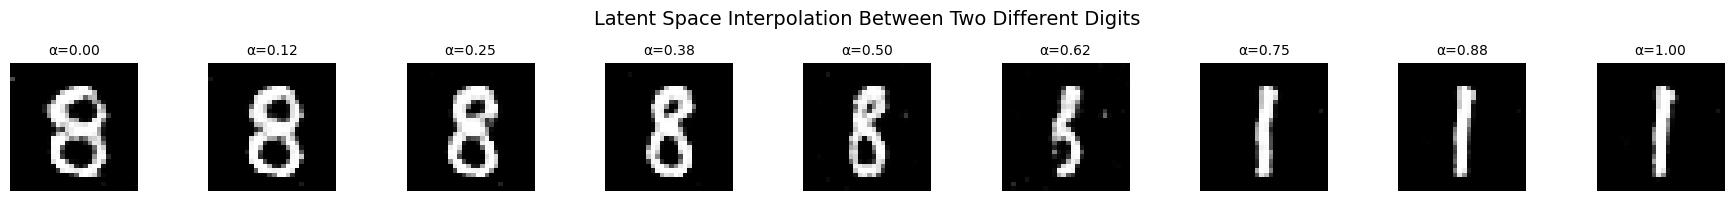

Interpolation from digit at index 0 to digit at index 50
Total images: 9 (including start and end points)


In [23]:
# Perform interpolation
interpolated_imgs, alphas = interpolate_latent_space(generator, z1, z2, n_steps=7)

# Display interpolation results
fig, axes = plt.subplots(1, 9, figsize=(18, 2))

for i, (img, alpha) in enumerate(zip(interpolated_imgs, alphas)):
    img_display = (img[0, 0].cpu() + 1) / 2  # Denormalize
    axes[i].imshow(img_display.numpy(), cmap='gray')
    axes[i].set_title(f'α={alpha:.2f}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Latent Space Interpolation Between Two Different Digits', fontsize=14)
plt.tight_layout()
plt.savefig('interpolation_result.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Interpolation from digit at index {idx1} to digit at index {idx2}")
print(f"Total images: {len(interpolated_imgs)} (including start and end points)")

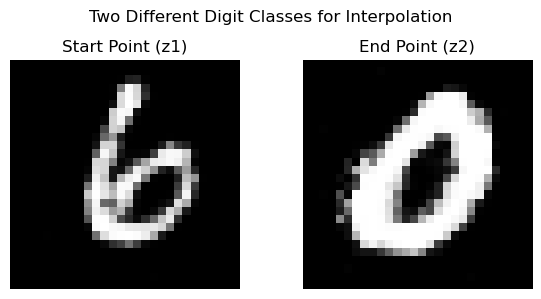

In [24]:
# Alternative: Use fixed random seeds to ensure reproducible different-looking digits
torch.manual_seed(42)
z1_fixed = torch.randn(1, latent_dim).to(device)

torch.manual_seed(123)
z2_fixed = torch.randn(1, latent_dim).to(device)

# Show the two endpoint images
generator.eval()
with torch.no_grad():
    img1 = generator(z1_fixed)
    img2 = generator(z2_fixed)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow((img1[0, 0].cpu() + 1) / 2, cmap='gray')
axes[0].set_title('Start Point (z1)')
axes[0].axis('off')
axes[1].imshow((img2[0, 0].cpu() + 1) / 2, cmap='gray')
axes[1].set_title('End Point (z2)')
axes[1].axis('off')
plt.suptitle('Two Different Digit Classes for Interpolation')
plt.tight_layout()
plt.show()

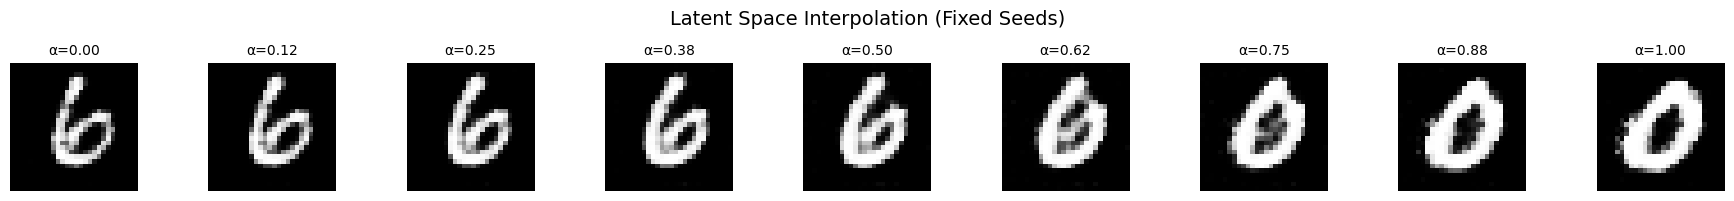

In [25]:
# Perform interpolation with fixed seeds
interpolated_imgs_fixed, alphas_fixed = interpolate_latent_space(generator, z1_fixed, z2_fixed, n_steps=7)

# Display interpolation results
fig, axes = plt.subplots(1, 9, figsize=(18, 2))

for i, (img, alpha) in enumerate(zip(interpolated_imgs_fixed, alphas_fixed)):
    img_display = (img[0, 0].cpu() + 1) / 2  # Denormalize
    axes[i].imshow(img_display.numpy(), cmap='gray')
    axes[i].set_title(f'α={alpha:.2f}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Latent Space Interpolation (Fixed Seeds)', fontsize=14)
plt.tight_layout()
plt.savefig('interpolation_fixed_seeds.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

### Task 2: Training Progress
The generated images show clear improvement from random noise at the start of training to recognizable digit-like patterns at the end.

### Task 3: Latent Space Interpolation
The interpolation demonstrates that the GAN has learned a smooth latent space where:
- Nearby points in latent space produce similar images
- Moving between two points produces a gradual transition
- The generator can produce intermediate forms between different digit classes